In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import MultipleLocator
import pandas as pd
import os

## Trainning stability 

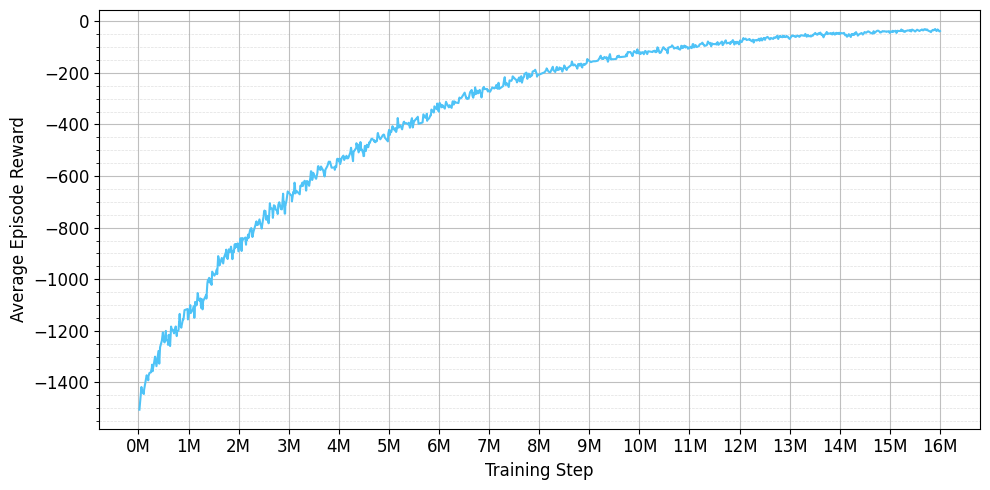

In [3]:
df = pd.read_csv('train-DoubleDQN_OnRL-AvgEpRew.csv') 

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['Step'], df['Value'], color='#4fc3f7', linewidth=1.5)

ax.set_xlabel('Training Step',fontsize=12)
ax.set_ylabel('Average Episode Reward',fontsize=12)
# ax.set_title('Average Episode Reward vs Training Steps')

# X-axis: show 0M, 1M, ..., 16M
ax.xaxis.set_major_locator(MultipleLocator(1_000_000))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1_000_000)}M'))

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
# Y-axis ticks
ax.yaxis.set_major_locator(MultipleLocator(200))
ax.yaxis.set_minor_locator(MultipleLocator(50))

# Grid
ax.grid(which='major', axis='y', linestyle='-', linewidth=0.8, alpha=0.8)
ax.grid(which='minor', axis='y', linestyle='--', linewidth=0.5, alpha=0.4)
ax.grid(which='major', axis='x', linestyle='-', linewidth=0.8, alpha=0.8)

plt.tight_layout()
plt.savefig('training_reward_curve.pdf', dpi=150, bbox_inches='tight')
plt.show()

## metrics_summary in CSV

In [5]:
# Directory containing the CSV files
DATA_DIR = ["./test_seed_train","./test_seed_test"]

# Map filenames to model names
file_model_map = {
    "DoubleDQN_OnRL.csv":"On-DDQN",
    "DoubleDQN_OffRL4e6.csv":"Off-DDQN-4e6",
    "BCQ4e6.csv":"BCQ-4e6",
    "DoubleDQN_OffRL4e6Clean.csv":"Off-DDQN-4e6-Clean",
    "BCQ4e6Clean.csv":"BCQ-4e6-Clean",
    "DoubleDQN_OffRL4e6CleanShuffle.csv":"Off-DDQN-4e6-Clean-Shuffle",
    "BCQ4e6CleanShuffle.csv":"BCQ-4e6-Clean-Shuffle",
    "DoubleDQN_OffRL4e6Shuffle.csv":"Off-DDQN-4e6-Shuffle",
    "BCQ4e6Shuffle.csv":"BCQ-4e6-Shuffle",
    "DoubleDQN_OffRL8e6Clean.csv":"Off-DDQN-8e6-Clean",  
    "BCQ8e6Clean.csv":"BCQ-8e6-Clean",
}
for DIR in DATA_DIR:
    records = []

    for file_name, model_name in file_model_map.items():
        filepath = os.path.join(DIR, file_name)

    
        df = pd.read_csv(filepath)

        record = {
            "Model": model_name,

            # Episode length
            "avg_episode_length": df["episode_length"].mean(),
            "min_episode_length": df["episode_length"].min(),
            "max_episode_length": df["episode_length"].max(),

            # Vehicle speed
            "avg_vehicle_speed": df["episode_avg_speed"].mean(),
            "min_vehicle_speed": df["episode_avg_speed"].min(),
            "max_vehicle_speed": df["episode_avg_speed"].max(),

            # Episode total reward
            "avg_episode_total_reward": df["episode_total_reward"].mean(),
            "min_episode_total_reward": df["episode_total_reward"].min(),
            "max_episode_total_reward": df["episode_total_reward"].max(),

            # Total counts
            "total_nb_lc": df["episode_nb_lc"].sum(),
            "avg_episode_nb_lc": df["episode_nb_lc"].mean(),
            "total_nb_min_gap_violation": df["episode_nb_mingap_violation"].sum(),
            "total_nb_invalide_lc": df["episode_nb_invalide_lc"].sum(),
            "total_nb_vehicle_collision": df["episode_nb_vehicle_collision"].sum(),
        }

        records.append(record)
        print(f"✓ Processed: {model_name} ({len(df)} episodes)")

    output_path = "./metrics_summary_"+DIR[7:]+".csv"
    

    summary_df = pd.DataFrame(records).set_index("Model")
    summary_df = summary_df.round(2)
    summary_df = summary_df.T
    summary_df.index.name = "Metric"
    summary_df.to_csv(output_path)


✓ Processed: On-DDQN (8 episodes)
✓ Processed: Off-DDQN-4e6 (8 episodes)
✓ Processed: BCQ-4e6 (8 episodes)
✓ Processed: Off-DDQN-4e6-Clean (8 episodes)
✓ Processed: BCQ-4e6-Clean (8 episodes)
✓ Processed: Off-DDQN-4e6-Clean-Shuffle (8 episodes)
✓ Processed: BCQ-4e6-Clean-Shuffle (8 episodes)
✓ Processed: Off-DDQN-4e6-Shuffle (8 episodes)
✓ Processed: BCQ-4e6-Shuffle (8 episodes)
✓ Processed: Off-DDQN-8e6-Clean (8 episodes)
✓ Processed: BCQ-8e6-Clean (8 episodes)
✓ Processed: On-DDQN (50 episodes)
✓ Processed: Off-DDQN-4e6 (50 episodes)
✓ Processed: BCQ-4e6 (50 episodes)
✓ Processed: Off-DDQN-4e6-Clean (50 episodes)
✓ Processed: BCQ-4e6-Clean (50 episodes)
✓ Processed: Off-DDQN-4e6-Clean-Shuffle (50 episodes)
✓ Processed: BCQ-4e6-Clean-Shuffle (50 episodes)
✓ Processed: Off-DDQN-4e6-Shuffle (50 episodes)
✓ Processed: BCQ-4e6-Shuffle (50 episodes)
✓ Processed: Off-DDQN-8e6-Clean (50 episodes)
✓ Processed: BCQ-8e6-Clean (50 episodes)


In [6]:
# All seeds combined
print("\nProcessing: all seeds (combined)")
all_records = []

for file_name, model_name in file_model_map.items():
    dfs = [pd.read_csv(os.path.join(d, file_name)) for d in DATA_DIR]
    df = pd.concat(dfs, ignore_index=True)

    record = {
            "Model": model_name,

            # Episode length
            "avg_episode_length": df["episode_length"].mean(),
            "min_episode_length": df["episode_length"].min(),
            "max_episode_length": df["episode_length"].max(),

            # Vehicle speed
            "avg_vehicle_speed": df["episode_avg_speed"].mean(),
            "min_vehicle_speed": df["episode_avg_speed"].min(),
            "max_vehicle_speed": df["episode_avg_speed"].max(),

            # Episode total reward
            "avg_episode_total_reward": df["episode_total_reward"].mean(),
            "min_episode_total_reward": df["episode_total_reward"].min(),
            "max_episode_total_reward": df["episode_total_reward"].max(),

            # Total counts
            "total_nb_lc": df["episode_nb_lc"].sum(),
            "avg_episode_nb_lc": df["episode_nb_lc"].mean(),
            "total_nb_min_gap_violation": df["episode_nb_mingap_violation"].sum(),
            "total_nb_invalide_lc": df["episode_nb_invalide_lc"].sum(),
            "total_nb_vehicle_collision": df["episode_nb_vehicle_collision"].sum(),
        }
    all_records.append(record)
    print(f"✓ Processed: {model_name} ({len(df)} episodes)")

summary_df = pd.DataFrame(all_records).set_index("Model")
summary_df = summary_df.round(2).T
summary_df.index.name = "Metric"
summary_df.to_csv("./metrics_summary_all_seeds.csv")


Processing: all seeds (combined)
✓ Processed: On-DDQN (58 episodes)
✓ Processed: Off-DDQN-4e6 (58 episodes)
✓ Processed: BCQ-4e6 (58 episodes)
✓ Processed: Off-DDQN-4e6-Clean (58 episodes)
✓ Processed: BCQ-4e6-Clean (58 episodes)
✓ Processed: Off-DDQN-4e6-Clean-Shuffle (58 episodes)
✓ Processed: BCQ-4e6-Clean-Shuffle (58 episodes)
✓ Processed: Off-DDQN-4e6-Shuffle (58 episodes)
✓ Processed: BCQ-4e6-Shuffle (58 episodes)
✓ Processed: Off-DDQN-8e6-Clean (58 episodes)
✓ Processed: BCQ-8e6-Clean (58 episodes)


# Episode reward per seed per episode 

In [7]:
# Directory containing the CSV files
DATA_DIR = ["./test_seed_train","./test_seed_test"]

# Map filenames to model names
file_model_map = {
    "DoubleDQN_OnRL.csv":"On-DDQN",
    "DoubleDQN_OffRL4e6.csv":"Off-DDQN 4e6",
    "BCQ4e6.csv":"BCQ 4e6",
    "DoubleDQN_OffRL4e6Clean.csv":"Off-DDQN 4e6-Clean",
    "BCQ4e6Clean.csv":"BCQ 4e6-Clean",
    "DoubleDQN_OffRL4e6CleanShuffle.csv":"Off-DDQN 4e6-Clean-Shuffle",
    "BCQ4e6CleanShuffle.csv":"BCQ 4e6-Clean-Shuffle",
    "DoubleDQN_OffRL4e6Shuffle.csv":"Off-DDQN 4e6-Shuffle",
    "BCQ4e6Shuffle.csv":"BCQ 4e6-Shuffle",
    "DoubleDQN_OffRL8e6Clean.csv":"Off-DDQN 8e6-Clean",  
    "BCQ8e6Clean.csv":"BCQ 8e6-Clean",
}
for DIR in DATA_DIR:
    episode_reward_list = []

    for file_name, model_name in file_model_map.items():
        filepath = os.path.join(DIR, file_name)

    
        df = pd.read_csv(filepath)

        s = df.set_index("seed")["episode_total_reward"].rename(model_name)
        episode_reward_list.append(s)

    result = pd.concat(episode_reward_list, axis=1)
    result = result.round(2)
    result.index.name = "seed"

    output_path = "./episode_reward_"+DIR[7:]+".csv"
    result.to_csv(output_path)